# Notebook demonstrativo: visualização do erro de Taylor

Este notebook foi preparado para apoiar a **Aula 2 — Aproximação Polinomial e Séries de Taylor**.

Objetivos:
- comparar funções reais com seus polinômios de Taylor;
- visualizar o erro de truncamento;
- discutir aproximação local e ordem do erro.


## 1. Bibliotecas

Usaremos apenas `numpy` e `matplotlib`.
Nas versões mais recentes do `numpy`, o atalho `np.math` foi removido. Em versões anteriores este atalho era apenas um "espelho" do módulo `math` nativo do __Python__ para _arrays_, mas a equipe de mantenedores decidiu limpar a biblioteca para evitar redundâncias. Desta forma a função `factorial` foi importada do `scipy`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import factorial

## 2. Funções auxiliares

As funções abaixo produzem:
- gráfico da função real e das aproximações de Taylor;
- gráfico do erro absoluto;
- impressão do erro em pontos específicos.


In [2]:
def plot_func_and_taylor(x, f_real, approximations, title):
    plt.figure(figsize=(9, 5))
    plt.plot(x, f_real, label='Função real', linewidth=2)
    for label, y in approximations:
        plt.plot(x, y, label=label)
    plt.axhline(0, linewidth=0.8)
    plt.axvline(0, linewidth=0.8)
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_abs_error(x, f_real, approximations, title):
    plt.figure(figsize=(9, 5))
    for label, y in approximations:
        err = np.abs(f_real - y)
        plt.plot(x, err, label=f'Erro: {label}')
    plt.yscale('log')
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('Erro absoluto (escala log)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


def print_pointwise_error(points, f, approximations_dict):
    print('Comparação pontual:')
    for xp in points:
        exact = f(xp)
        print(f'\nx = {xp:.4f} | valor exato = {exact:.10f}')
        for label, g in approximations_dict.items():
            approx = g(xp)
            err = abs(exact - approx)
            err_relativo = err / np.abs(exact) if exact != 0 else float('inf')
            print(f'  {label:<18} approx = {approx:.10f} | erro absoluto = {err:.3e} | erro relativo = {err_relativo:.3e}')


## 3. Exemplo 1 — $e^x$ em torno de $x=0$

Série de Taylor de Maclaurin:

$$
e^x = 1 + x + \frac{x^2}{2!} + \frac{x^3}{3!} + \frac{x^4}{4!} + \cdots
$$

Aqui vamos comparar aproximações de ordem 1, 2 e 4.

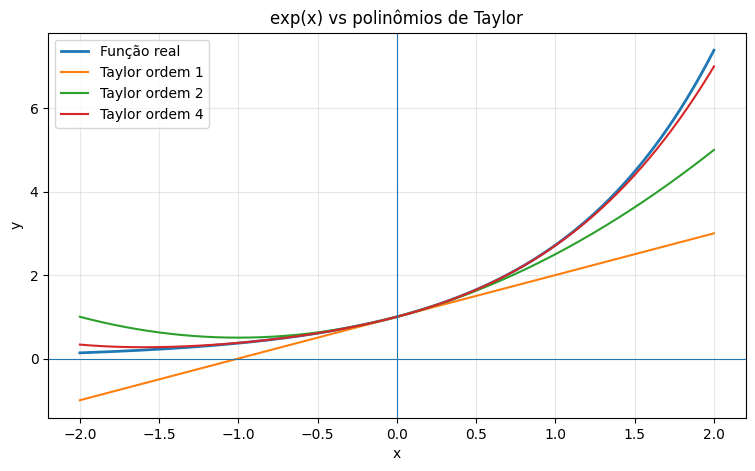

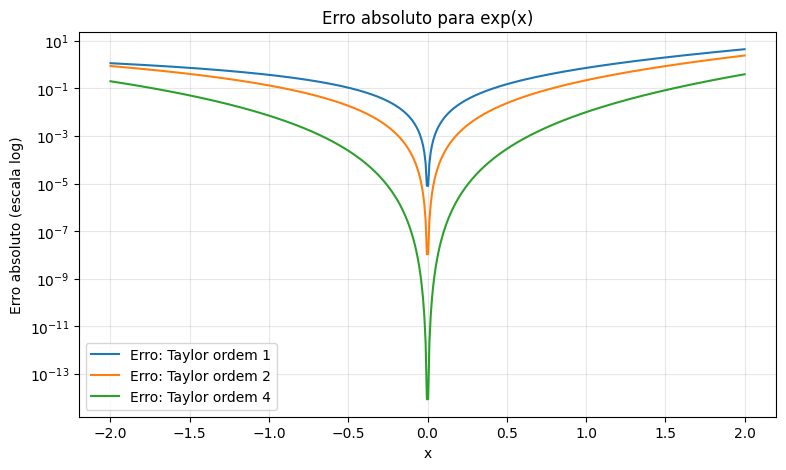

In [3]:
x = np.linspace(-2, 2, 500)
f_real = np.exp(x)

T1 = 1 + x
T2 = 1 + x + x**2/2
T4 = 1 + x + x**2/2 + x**3/6 + x**4/24

approx_list = [
    ('Taylor ordem 1', T1),
    ('Taylor ordem 2', T2),
    ('Taylor ordem 4', T4),
]

plot_func_and_taylor(x, f_real, approx_list, 'exp(x) vs polinômios de Taylor')
plot_abs_error(x, f_real, approx_list, 'Erro absoluto para exp(x)')


In [4]:
f = np.exp
approximations = {
    'Taylor ordem 1': lambda z: 1 + z,
    'Taylor ordem 2': lambda z: 1 + z + z**2/2,
    'Taylor ordem 4': lambda z: 1 + z + z**2/2 + z**3/6 + z**4/24,
}
print_pointwise_error([0.1, 0.5, 1.0, 1.5], f, approximations)


Comparação pontual:

x = 0.1000 | valor exato = 1.1051709181
  Taylor ordem 1     approx = 1.1000000000 | erro absoluto = 5.171e-03 | erro relativo = 4.679e-03
  Taylor ordem 2     approx = 1.1050000000 | erro absoluto = 1.709e-04 | erro relativo = 1.547e-04
  Taylor ordem 4     approx = 1.1051708333 | erro absoluto = 8.474e-08 | erro relativo = 7.668e-08

x = 0.5000 | valor exato = 1.6487212707
  Taylor ordem 1     approx = 1.5000000000 | erro absoluto = 1.487e-01 | erro relativo = 9.020e-02
  Taylor ordem 2     approx = 1.6250000000 | erro absoluto = 2.372e-02 | erro relativo = 1.439e-02
  Taylor ordem 4     approx = 1.6484375000 | erro absoluto = 2.838e-04 | erro relativo = 1.721e-04

x = 1.0000 | valor exato = 2.7182818285
  Taylor ordem 1     approx = 2.0000000000 | erro absoluto = 7.183e-01 | erro relativo = 2.642e-01
  Taylor ordem 2     approx = 2.5000000000 | erro absoluto = 2.183e-01 | erro relativo = 8.030e-02
  Taylor ordem 4     approx = 2.7083333333 | erro absoluto = 9.94

### Discussão

- perto de $x=0$, a aproximação é muito boa;
- à medida que nos afastamos do ponto de expansão, o erro cresce;
- ordens maiores tendem a melhorar a aproximação local.


## 4. Exemplo 2 — $\sin(x)$ em torno de $x=0$

$$
\sin(x) = x - \frac{x^3}{3!} + \frac{x^5}{5!} - \cdots
$$

Vamos comparar as ordens 1, 3 e 5.

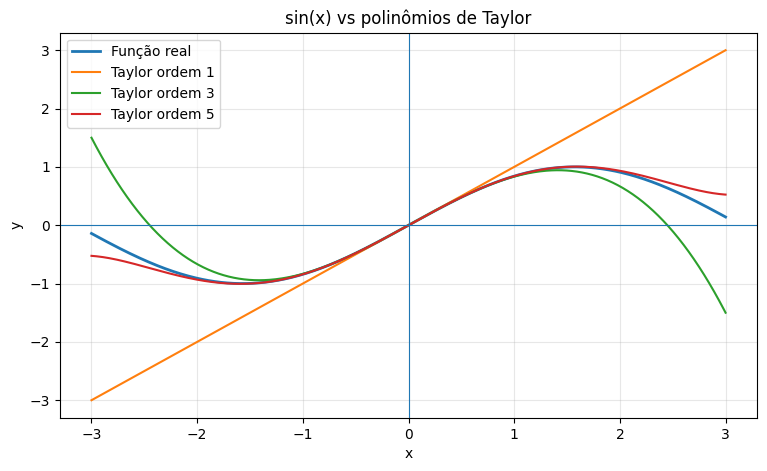

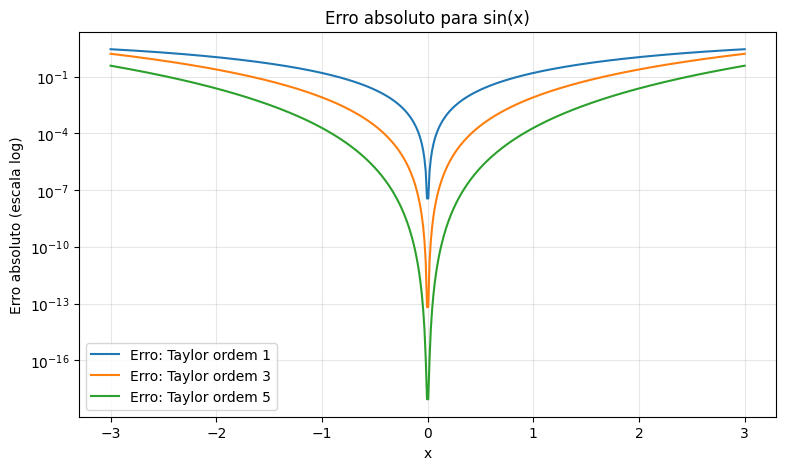

In [5]:
x = np.linspace(-3, 3, 500)
f_real = np.sin(x)

T1 = x
T3 = x - x**3/6
T5 = x - x**3/6 + x**5/120

approx_list = [
    ('Taylor ordem 1', T1),
    ('Taylor ordem 3', T3),
    ('Taylor ordem 5', T5),
]

plot_func_and_taylor(x, f_real, approx_list, 'sin(x) vs polinômios de Taylor')
plot_abs_error(x, f_real, approx_list, 'Erro absoluto para sin(x)')


In [6]:
f = np.sin
approximations = {
    'Taylor ordem 1': lambda z: z,
    'Taylor ordem 3': lambda z: z - z**3/6,
    'Taylor ordem 5': lambda z: z - z**3/6 + z**5/120,
}
print_pointwise_error([0.1, 0.5, 1.0, 2.0], f, approximations)


Comparação pontual:

x = 0.1000 | valor exato = 0.0998334166
  Taylor ordem 1     approx = 0.1000000000 | erro absoluto = 1.666e-04 | erro relativo = 1.669e-03
  Taylor ordem 3     approx = 0.0998333333 | erro absoluto = 8.331e-08 | erro relativo = 8.345e-07
  Taylor ordem 5     approx = 0.0998334167 | erro absoluto = 1.984e-11 | erro relativo = 1.987e-10

x = 0.5000 | valor exato = 0.4794255386
  Taylor ordem 1     approx = 0.5000000000 | erro absoluto = 2.057e-02 | erro relativo = 4.291e-02
  Taylor ordem 3     approx = 0.4791666667 | erro absoluto = 2.589e-04 | erro relativo = 5.400e-04
  Taylor ordem 5     approx = 0.4794270833 | erro absoluto = 1.545e-06 | erro relativo = 3.222e-06

x = 1.0000 | valor exato = 0.8414709848
  Taylor ordem 1     approx = 1.0000000000 | erro absoluto = 1.585e-01 | erro relativo = 1.884e-01
  Taylor ordem 3     approx = 0.8333333333 | erro absoluto = 8.138e-03 | erro relativo = 9.671e-03
  Taylor ordem 5     approx = 0.8416666667 | erro absoluto = 1.95

### Discussão

- a aproximação $\sin(x) \approx x$ funciona bem apenas para pequenos valores de $x$;
- a ordem 5 amplia a faixa de boa aproximação, mas ainda é uma aproximação local.


## 5. Exemplo 3 — $\ln(1+x)$ em torno de $x=0$

$$
\ln(1+x) = x - \frac{x^2}{2} + \frac{x^3}{3} - \frac{x^4}{4} + \cdots
$$

Esse exemplo é útil para discutir também **domínio e convergência**.

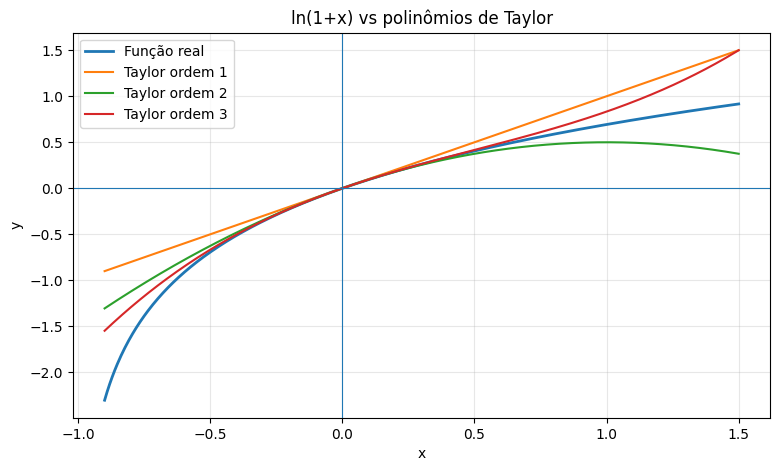

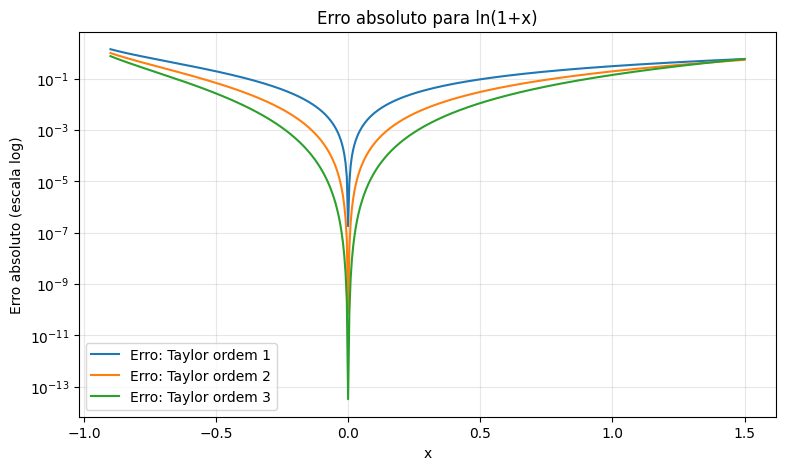

In [7]:
x = np.linspace(-0.9, 1.5, 500)
f_real = np.log(1 + x)

T1 = x
T2 = x - x**2/2
T3 = x - x**2/2 + x**3/3

approx_list = [
    ('Taylor ordem 1', T1),
    ('Taylor ordem 2', T2),
    ('Taylor ordem 3', T3),
]

plot_func_and_taylor(x, f_real, approx_list, 'ln(1+x) vs polinômios de Taylor')
plot_abs_error(x, f_real, approx_list, 'Erro absoluto para ln(1+x)')


### Discussão

- o comportamento perto de $x=-1$ é crítico;
- a série de Taylor é especialmente útil para discutir raio/faixa de convergência.


## 6. Efeito da ordem do polinômio em um ponto fixo

Agora vamos observar como o erro muda com a ordem do polinômio para um valor fixo de $x$.

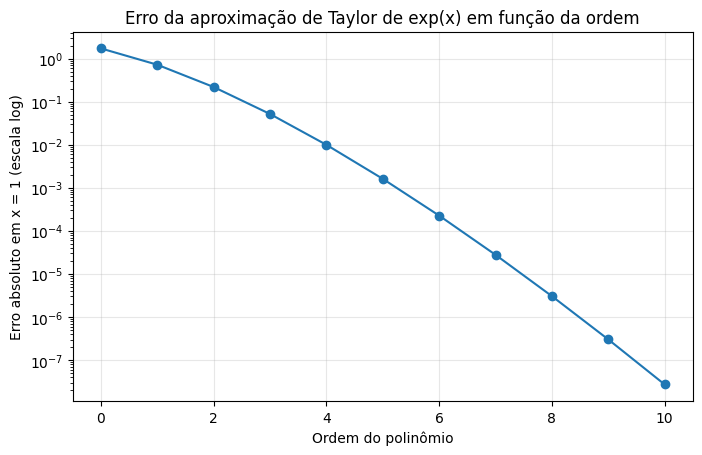

In [8]:
x0 = 1.0
exact = np.exp(x0)
orders = np.arange(0, 11)
errors = []

for n in orders:
    approx = sum(x0**k / factorial(k) for k in range(n + 1))
    errors.append(abs(exact - approx))

plt.figure(figsize=(8, 4.8))
plt.plot(orders, errors, marker='o')
plt.yscale('log')
plt.xlabel('Ordem do polinômio')
plt.ylabel('Erro absoluto em x = 1 (escala log)')
plt.title('Erro da aproximação de Taylor de exp(x) em função da ordem')
plt.grid(True, alpha=0.3)
plt.show()


## 7. Efeito da distância ao ponto de expansão

Mesmo um polinômio de ordem razoável pode perder qualidade quando nos afastamos do ponto de expansão.

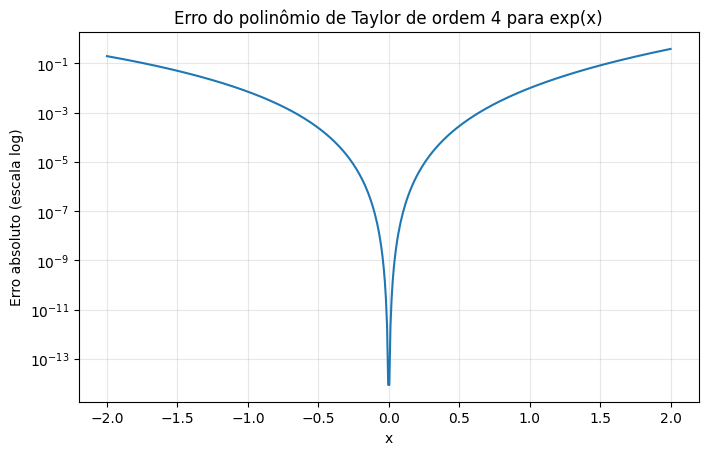

In [9]:
x = np.linspace(-2, 2, 500)
f_real = np.exp(x)
T4 = 1 + x + x**2/2 + x**3/6 + x**4/24
err = np.abs(f_real - T4)

plt.figure(figsize=(8, 4.8))
plt.plot(x, err)
plt.yscale('log')
plt.xlabel('x')
plt.ylabel('Erro absoluto (escala log)')
plt.title('Erro do polinômio de Taylor de ordem 4 para exp(x)')
plt.grid(True, alpha=0.3)
plt.show()


## 8. Conclusões

Pontos principais para discussão em sala:

1. a expansão de Taylor é uma **aproximação local**;
2. a qualidade depende da **ordem** e da **distância ao ponto de expansão**;
3. o termo de resto permite interpretar o **erro de truncamento**;
4. esse formalismo é a base de muitos métodos numéricos de derivação, integração e solução de equações.
